# Multi-Country ECH GREASE Analysis
This report provides a comprehensive, data-driven analysis of network behavior when ECH GREASE is enabled across global ISP networks. The objective is to identify potential network interference, assess deployment readiness, and provide detailed diagnostic data for network engineers.

> **How to (re-)run this notebook:**
> 
> 1. Ensure you have Python installed and activate your virtual environment (e.g., `source ../../workspace/.venv/bin/activate`).
> 2. Install the required libraries if you haven't already: `pip install pandas numpy matplotlib seaborn ipywidgets jupyter`.
> 3. Open this file in Jupyter Notebook (`jupyter notebook report.ipynb`) or an IDE (like VS Code), and execute the cells sequentially.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML

# Configure visualization settings
plt.rcParams['figure.figsize'] = (12, 7)
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

# Configuration
DOMAIN = "www_cloudflare_com" # Or "www_google_com", "cloudflare-ech_com"
DATA_DIR = f"{DOMAIN}/"
RESULTS_FILE = f"{DATA_DIR}results.csv"

print(f"Dataset initialized for domain: {DOMAIN}\nInput File: {RESULTS_FILE}")


Dataset initialized for domain: www_cloudflare_com
Input File: www_cloudflare_com/results.csv


## 1. Data Ingestion and Proxy Quality Assessment
Initial loading of the dataset. We evaluate the proxy integrity and establish a reliable baseline by validating the vantage points (using GeoDB ASN matching) exclusively on the control group where ECH GREASE is disabled (OFF).


,Count
Total Raw Requests,1596
GeoDB Matched Requests (Target for Analysis),1026
Unique Countries Tested,202
Unique ISPs Tested,740


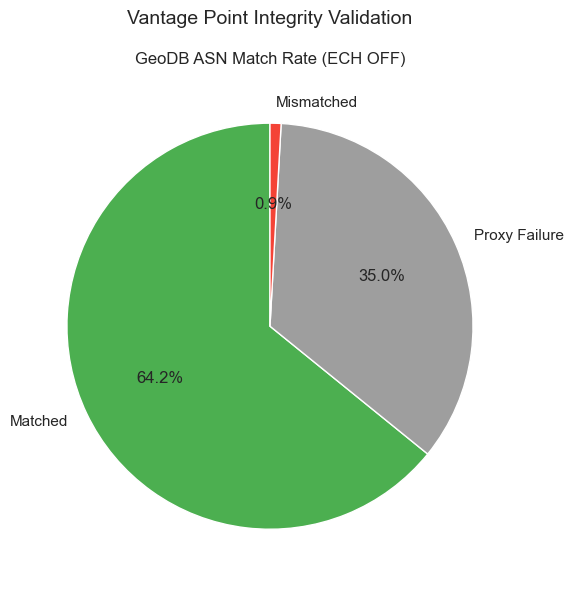

In [2]:
# Load dataset
try:
    df = pd.read_csv(RESULTS_FILE)
except FileNotFoundError:
    print(f"Error: Dataset {RESULTS_FILE} not found.")
    df = pd.DataFrame()

if not df.empty:
    # Map true/false to categories and handle nulls representing proxy/connection failures
    df['asn_match_label'] = df['asn_match'].map({True: 'Matched', False: 'Mismatched'}).fillna('Proxy Failure')

    # Keep original boolean for filtering where needed, but fill NAs as False just for those specific checks
    df['asn_match'] = df['asn_match'].fillna(False).astype(bool)

    # We do not filter out failed requests here (e.g., by missing exit_node_ip) 
    # because an ECH ON request might fail to connect entirely due to interference.
    # Instead, we focus our analysis on vantage points that are verified via GeoDB 
    # during their baseline (ECH OFF) test.
    df_valid = df.copy()
    df_off = df_valid[df_valid["ech_grease"] == False]
    
    total_requests = len(df)
    geodb_matched_requests = len(df[df['asn_match'] == True])
    unique_countries = df['country_name'].nunique()
    unique_isps = df['isp'].nunique()

    summary_data = {
        "Metric": ["Total Raw Requests", "GeoDB Matched Requests (Target for Analysis)", "Unique Countries Tested", "Unique ISPs Tested"],
        "Count": [total_requests, geodb_matched_requests, unique_countries, unique_isps]
    }
    summary_df = pd.DataFrame(summary_data).set_index("Metric")
    # Display table cleanly without index to avoid two-line headers
    summary_df.index.name = None
    display(summary_df)

    # Data Quality: Proxy Integrity (Baseline OFF Requests)
    plt.figure(figsize=(8, 6))
    
    color_map = {'Matched': '#4CAF50', 'Mismatched': '#F44336', 'Proxy Failure': '#9E9E9E'}

    asn_match_counts = df_off['asn_match_label'].value_counts()
    plt.pie(asn_match_counts, labels=asn_match_counts.index, autopct="%1.1f%%", startangle=90, colors=[color_map.get(x, '#333333') for x in asn_match_counts.index])
    plt.title("GeoDB ASN Match Rate (ECH OFF)")

    plt.suptitle("Vantage Point Integrity Validation", fontsize=14)
    plt.tight_layout()
    plt.show()


## 2. Global Connectivity Distribution
A simplistic "success rate" can mask underlying issues by grouping disparate failure modes. Here, we present the exact distribution of HTTP status codes and `curl` exit codes across all valid proxy connections, comparing ECH GREASE OFF vs. ON. This provides a high-resolution view of how the network state transitions when GREASE is introduced.


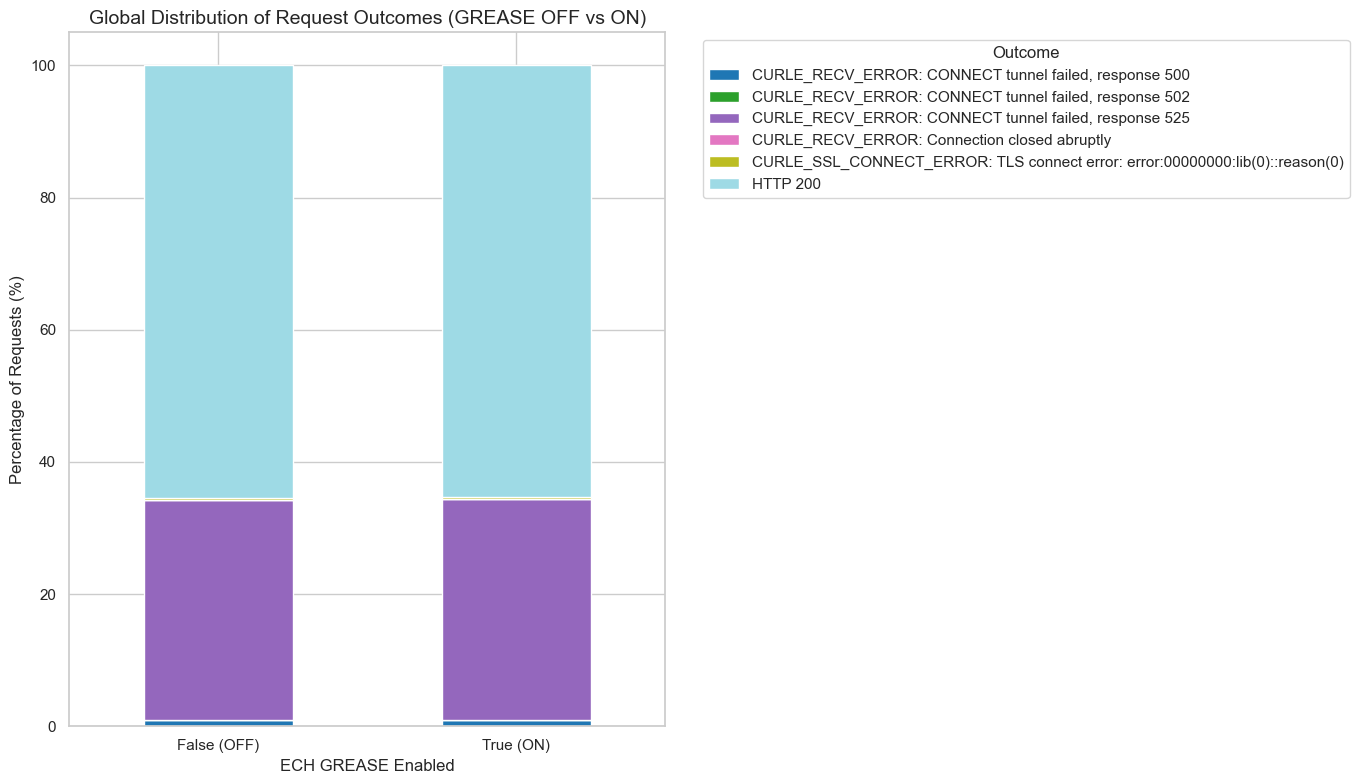

In [3]:
if not df_valid.empty:
    # Categorize outcome
    def categorize_outcome(row):
        if row['http_status'] >= 200 and row['http_status'] < 400:
            return f"HTTP {int(row['http_status'])}"
        elif row['http_status'] >= 400:
            return f"HTTP Error {int(row['http_status'])}"
        else:
            if pd.notna(row['curl_error_name']):
                err_name = row['curl_error_name']
                if err_name == 'CURLE_OPERATION_TIMEDOUT' or pd.isna(row['curl_error_message']):
                    return str(err_name)
                return f"{err_name}: {row['curl_error_message']}"
            return "Unknown Error"

    df_valid['outcome'] = df_valid.apply(categorize_outcome, axis=1)

    # Pivot for visualization
    outcome_dist = df_valid.groupby(['ech_grease', 'outcome']).size().unstack(fill_value=0)
    
    # Normalize to percentages
    outcome_pct = outcome_dist.div(outcome_dist.sum(axis=1), axis=0) * 100

    # Plot
    ax = outcome_pct.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')
    plt.title("Global Distribution of Request Outcomes (GREASE OFF vs ON)", fontsize=14)
    plt.xlabel("ECH GREASE Enabled")
    plt.ylabel("Percentage of Requests (%)")
    plt.xticks(ticks=[0, 1], labels=["False (OFF)", "True (ON)"], rotation=0)
    plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 3. Country-Level Connectivity and Interference Analysis
We pair the GREASE OFF and GREASE ON requests for each specific ISP within each country to measure deterministic degradation. 
We define a connection as 'successful' if it returns an HTTP status between 200 and 399. 
We classify ISPs into the following states based on their paired tests:
*   **Parity (Success):** Both OFF and ON succeeded.
*   **Parity (Consistent Failure):** Both OFF and ON failed with the same error (neutral impact).
*   **Degraded (Interference):** OFF succeeded, but ON failed. This is the primary indicator of ECH blocking.
*   **Improved:** OFF failed, but ON succeeded (rare, usually anomalous).
*   **Broken Proxy (Inconclusive):** Both failed, but with different network errors.


state,Broken Proxy (Inconclusive),Degraded (Interference),Parity (Consistent Failure),Parity (Success),Improved,Total ISPs Tested,Interference Rate (%)
country_name,,,,,,,
Burkina Faso,0,1,1,1,0,3,33.333333
Russian Federation,0,0,14,13,0,27,0.000000
United States,0,0,7,9,0,16,0.000000
Iraq,0,0,6,8,0,14,0.000000
Canada,0,0,3,9,0,12,0.000000
Japan,0,0,5,7,0,12,0.000000
Kazakhstan,0,0,2,10,0,12,0.000000
Pakistan,0,0,4,8,0,12,0.000000
Spain,0,0,4,8,0,12,0.000000


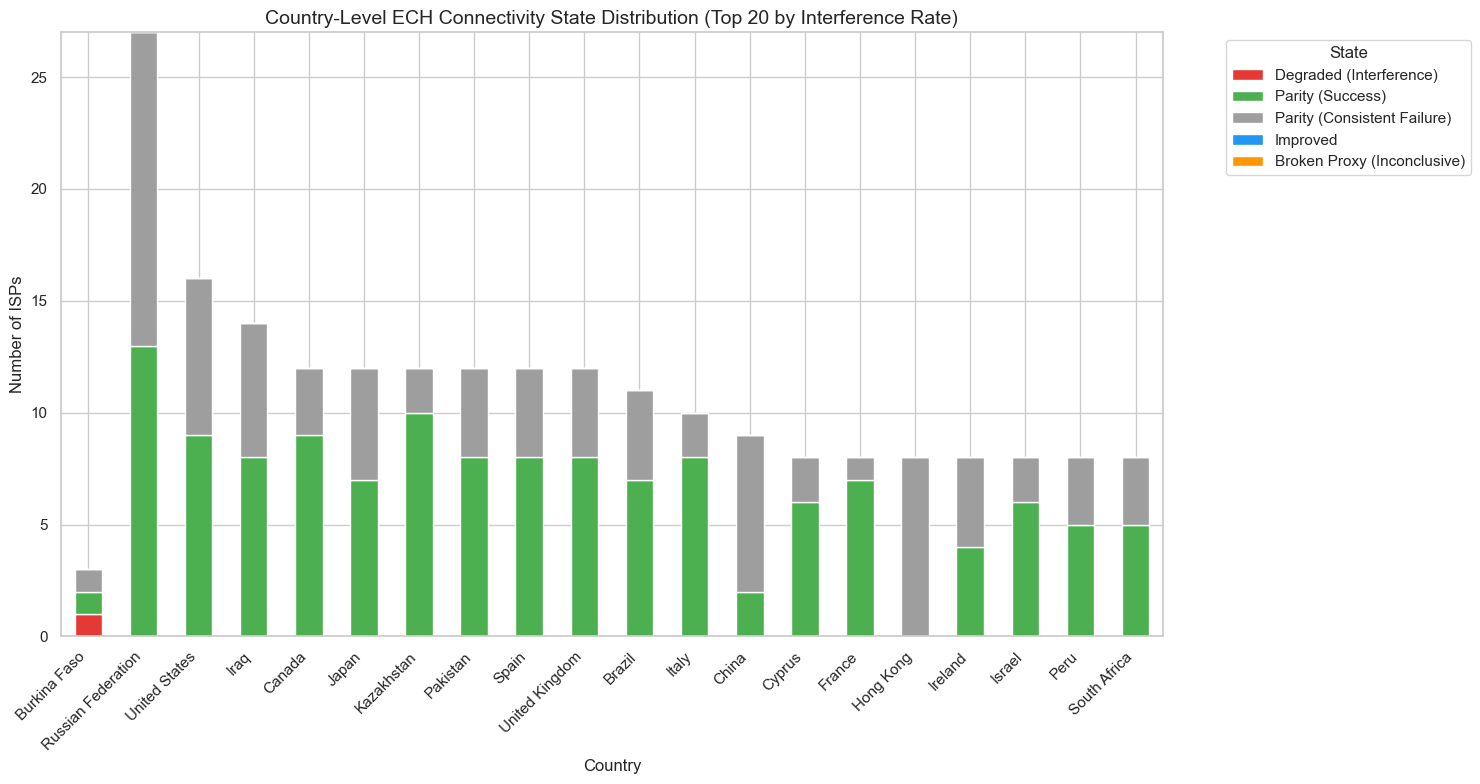

In [4]:
if not df_valid.empty:
    # Pair the data
    df_on = df_valid[df_valid["ech_grease"] == True].set_index(["country_code", "country_name", "isp"])
    df_off = df_valid[df_valid["ech_grease"] == False].set_index(["country_code", "country_name", "isp"])
    paired_df = df_off.join(df_on, lsuffix="_off", rsuffix="_on", how="inner")
    
    # Define success strictly as receiving a valid HTTP response
    paired_df["success_off"] = (paired_df["http_status_off"] >= 200) & (paired_df["http_status_off"] < 400)
    paired_df["success_on"] = (paired_df["http_status_on"] >= 200) & (paired_df["http_status_on"] < 400)

    # Classify the delta
    def classify_delta(row):
        if row["success_off"] and not row["success_on"]:
            return "Degraded (Interference)"
        elif not row["success_off"] and row["success_on"]:
            return "Improved"
        elif row["success_off"] and row["success_on"]:
            return "Parity (Success)"
        else:
            if row["curl_error_name_off"] == row["curl_error_name_on"]:
                return "Parity (Consistent Failure)"
            else:
                return "Broken Proxy (Inconclusive)"

    paired_df["state"] = paired_df.apply(classify_delta, axis=1)

    # Aggregate by Country
    country_summary = paired_df.groupby("country_name")["state"].value_counts().unstack(fill_value=0)
    
    # Ensure columns exist
    for col in ["Degraded (Interference)", "Parity (Success)", "Parity (Consistent Failure)", "Improved", "Broken Proxy (Inconclusive)"]:
        if col not in country_summary.columns:
            country_summary[col] = 0
            
    country_summary["Total ISPs Tested"] = country_summary.sum(axis=1)
    country_summary["Interference Rate (%)"] = (country_summary["Degraded (Interference)"] / country_summary["Total ISPs Tested"]) * 100
    
    # Sort by Interference Rate and then Total ISPs
    country_summary = country_summary.sort_values(by=["Interference Rate (%)", "Total ISPs Tested"], ascending=[False, False])
    
    display(HTML("<h3>Country-Level State Distribution</h3>"))
    # Use a scrollable div to display the full table without cluttering the notebook
    scrollable_table = f'<div style="max-height: 400px; overflow-y: auto;">{country_summary.to_html(classes="dataframe")}</div>'
    display(HTML(scrollable_table))

    # Absolute State Distribution Stacked Bar Chart
    if not country_summary.empty:
        # Custom Color Palette
        color_map = {
            "Degraded (Interference)": "#E53935",     # Red
            "Parity (Success)": "#4CAF50",            # Green
            "Parity (Consistent Failure)": "#9E9E9E", # Gray
            "Improved": "#2196F3",                    # Blue
            "Broken Proxy (Inconclusive)": "#FF9800"  # Orange
        }
        
        state_cols = ["Degraded (Interference)", "Parity (Success)", "Parity (Consistent Failure)", "Improved", "Broken Proxy (Inconclusive)"]
        # Ensure only columns that exist in the dataframe are used for plotting
        active_cols = [col for col in state_cols if col in country_summary.columns]
        plot_colors = [color_map.get(col, "#333333") for col in active_cols]

        # Sort by Interference Rate (Descending) then by Volume
        top_20_interfered = country_summary.sort_values(by=["Interference Rate (%)", "Total ISPs Tested"], ascending=[False, False]).head(20)
        
        ax = top_20_interfered[active_cols].plot(kind='bar', stacked=True, figsize=(15, 8), color=plot_colors)
        plt.title("Country-Level ECH Connectivity State Distribution (Top 20 by Interference Rate)", fontsize=14)
        plt.xlabel("Country")
        plt.ylabel("Number of ISPs")
        plt.xticks(rotation=45, ha='right')
        plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("No paired data available for visualization.")


## 4. Interference Error Anatomy
For the subset of connections classified as **Degraded (Interference)**, we analyze the specific network errors generated by `curl` when GREASE is enabled.
Understanding whether the failure is a TCP Reset (`CURLE_RECV_ERROR`), a Timeout (`CURLE_OPERATION_TIMEDOUT`), or an SSL Handshake failure (`CURLE_SSL_CONNECT_ERROR`) provides critical diagnostic signals to network engineers regarding the behavior of the interfering middleboxes.


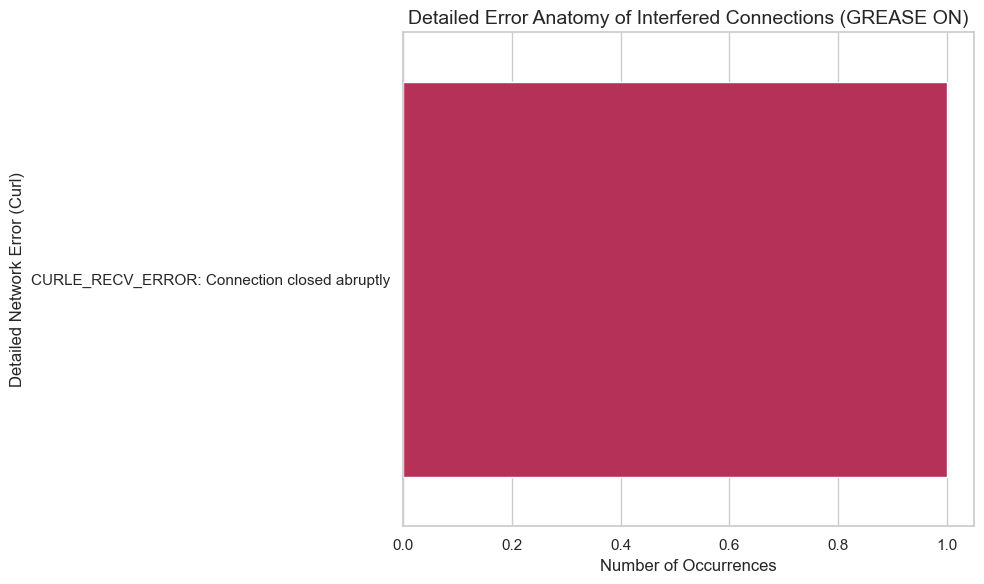

full_error_context,CURLE_RECV_ERROR: Connection closed abruptly
country_name,
Burkina Faso,1


In [5]:
if not df_valid.empty and "state" in paired_df.columns:
    degraded_df = paired_df[paired_df["state"] == "Degraded (Interference)"]
    
    if not degraded_df.empty:
        # Use both error name and message for a more detailed anatomy, excluding messages for timeouts
        def get_full_error(row):
            err_name = row['curl_error_name_on']
            if err_name == 'CURLE_OPERATION_TIMEDOUT' or pd.isna(row['curl_error_message_on']):
                return str(err_name)
            return f"{err_name}: {row['curl_error_message_on']}"
            
        degraded_df['full_error_context'] = degraded_df.apply(get_full_error, axis=1)
        error_counts = degraded_df["full_error_context"].value_counts()
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=error_counts.values, y=error_counts.index, hue=error_counts.index, palette="rocket", legend=False)
        plt.title("Detailed Error Anatomy of Interfered Connections (GREASE ON)", fontsize=14)
        plt.xlabel("Number of Occurrences")
        plt.ylabel("Detailed Network Error (Curl)")
        plt.tight_layout()
        plt.show()
        
        display(HTML("<h3>Detailed Breakdown of Interference Errors and Messages by Country</h3>"))
        error_detail = degraded_df.groupby(["country_name", "full_error_context"]).size().unstack(fill_value=0)
        display(error_detail)
    else:
        print("No interference data available for error anatomy analysis.")


## 5. Interactive Data Explorer
Use the controls below to drill down into the raw data for specific countries or individual Connection States. This tool exposes the raw metrics, ASNs, and HTTP/Curl statuses, enabling detailed, row-level inspection of all vantage points.


In [6]:
if not df_valid.empty and "state" in paired_df.columns:
    # 1. Column Renaming and Pre-processing
    display_df = paired_df.reset_index().copy()
    display_df = display_df.rename(columns={
        "country_name": "Country",
        "isp": "ISP",
        "state": "Connection State",
        "geodb_asn_on": "GeoDB ASN",
        "geodb_as_name_on": "GeoDB AS Name",
        "http_connect_status_off": "Proxy HTTP (OFF)",
        "http_connect_status_on": "Proxy HTTP (ON)",
        "http_status_off": "HTTP (OFF)",
        "http_status_on": "HTTP (ON)",
        "curl_error_name_off": "Error (OFF)",
        "curl_error_message_off": "Error Message (OFF)",
        "curl_error_name_on": "Error (ON)",
        "curl_error_message_on": "Error Message (ON)",
        "total_time_ms_off": "Total Time ms (OFF)",
        "total_time_ms_on": "Total Time ms (ON)"
    })
    
    # Select final display columns (Total Time instead of TLS)
    cols_to_show = ["Country", "ISP", "Connection State", "GeoDB ASN", "GeoDB AS Name", 
                    "Proxy HTTP (OFF)", "Proxy HTTP (ON)", "HTTP (OFF)", "HTTP (ON)", 
                    "Error (OFF)", "Error Message (OFF)", "Error (ON)", "Error Message (ON)", 
                    "Total Time ms (OFF)", "Total Time ms (ON)"]
    display_df = display_df[cols_to_show]
    
    # 2. Privacy & Cleaning: Hide repetitive timeout messages and clean NAs
    for msg_col in ["Error Message (OFF)", "Error Message (ON)"]:
        err_col = msg_col.replace(" Message", "")
        if msg_col in display_df.columns and err_col in display_df.columns:
            display_df.loc[display_df[err_col] == "CURLE_OPERATION_TIMEDOUT", msg_col] = ""

    # Format numeric columns (remove .0 and replace <NA> with empty string)
    formatted_df = display_df.copy()
    num_cols = ["GeoDB ASN", "Proxy HTTP (OFF)", "Proxy HTTP (ON)", "HTTP (OFF)", "HTTP (ON)", "Total Time ms (OFF)", "Total Time ms (ON)"]
    for col in num_cols:
        if col in formatted_df.columns:
            formatted_df[col] = formatted_df[col].astype('Int64').astype(str).replace('<NA>', '')
    
    # Final string cleaning for display
    formatted_df = formatted_df.fillna("")

    # 3. Interactive Widgets Setup
    country_dropdown = widgets.Dropdown(
        options=['All'] + sorted(display_df['Country'].unique().tolist()),
        value='All', description='Country:'
    )
    state_dropdown = widgets.Dropdown(
        options=['All'] + sorted(display_df['Connection State'].unique().tolist()),
        value='All', description='State:'
    )

    # Use a dedicated Output area for the table to avoid duplicate rendering
    table_output = widgets.Output()

    def update_view(change=None):
        with table_output:
            table_output.clear_output(wait=True)
            filtered = formatted_df
            if country_dropdown.value != 'All':
                filtered = filtered[filtered['Country'] == country_dropdown.value]
            if state_dropdown.value != 'All':
                filtered = filtered[filtered['Connection State'] == state_dropdown.value]
            
            display(HTML(f"<p><b>Showing {len(filtered)} records</b></p>"))
            html_table = filtered.to_html(classes="dataframe", max_rows=None, index=False)
            display(HTML(f'<div style="max-height: 500px; overflow-y: auto;">{html_table}</div>'))

    # Register observers
    country_dropdown.observe(update_view, names='value')
    state_dropdown.observe(update_view, names='value')

    # 4. Final Display: Render the UI containers first, then populate the table once.
    class ExplorerUI(widgets.VBox):
        def __repr__(self):
            return "Please rerun this notebook in a supported environment to view and interact with the data."
            
    display(ExplorerUI([widgets.HBox([country_dropdown, state_dropdown]), table_output]))
    update_view()
else:
    print("Data not available for interactive explorer.")


Please rerun this notebook in a supported environment to view and interact with the data.